Gambar: WhatsApp-Image-2025-10-10-at-19_27_34-12-_jpeg.rf.b6e2deccd14d8754cb124dbca66039ab.jpg
Jenis: Tangga (stair)
Ukuran: (1280, 960)

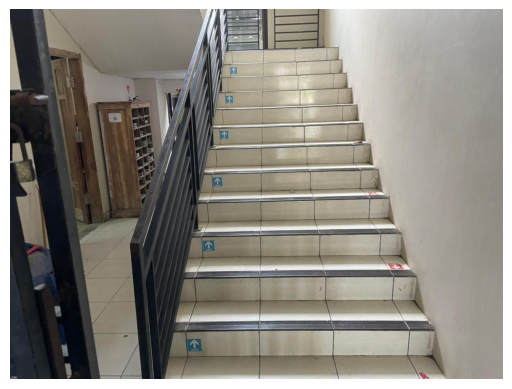

Gambar: WhatsApp-Image-2025-09-29-at-17_29_38-2-_jpeg.rf.877a8c31f2a86a7ca2126cc47be9c9fc.jpg
Jenis: Kursi (chair)
Ukuran: (4032, 3024)

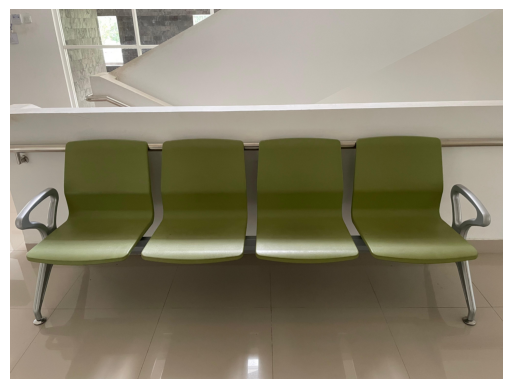

Gambar: WhatsApp-Image-2025-10-10-at-19_30_28-7-_jpeg.rf.a07ad85dc505563208eb2d1ddc9f0742.jpg
Jenis: Pintu (door)
Ukuran: (1280, 960)

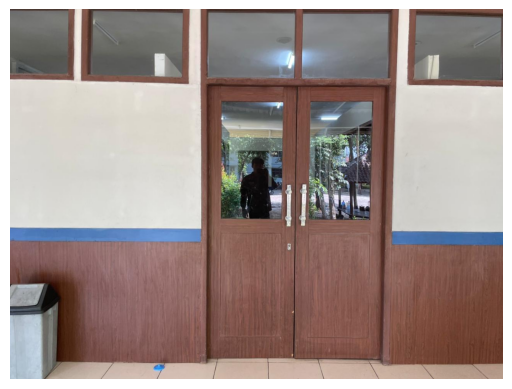

In [26]:
# Analisis Ukuran Gambar Sebelum Resizing (khusus untuk 3 file)
import os
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

class_map = {
    0: "Orang (person)",
    1: "Kursi (chair)",
    2: "Meja (table)",
    3: "Pintu (door)",
    4: "Tangga (stair)"
}

# === Path dataset hasil penggabungan ===
base_path = os.path.join("..", "dataset", "raw", "_merged")
images_path = os.path.join(base_path, "images")
labels_path = os.path.join(base_path, "labels")

# === Pastikan folder ada ===
if not (os.path.exists(images_path) and os.path.exists(labels_path)):
    raise FileNotFoundError(f"Folder tidak ditemukan: {images_path} atau {labels_path}")

# === File khusus yang akan dianalisis ===
target_files = [
    "WhatsApp-Image-2025-10-10-at-19_27_34-12-_jpeg.rf.b6e2deccd14d8754cb124dbca66039ab.jpg",
    "WhatsApp-Image-2025-09-29-at-17_29_38-2-_jpeg.rf.877a8c31f2a86a7ca2126cc47be9c9fc.jpg",
    "WhatsApp-Image-2025-10-10-at-19_30_28-7-_jpeg.rf.a07ad85dc505563208eb2d1ddc9f0742.jpg"
]

# === Ambil satu contoh gambar yang memiliki label ===
for filename in target_files:
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        label_name = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(labels_path, label_name)

        if not os.path.exists(label_path):
            continue

        try:
            with open(label_path, "r") as f:
                lines = f.readlines()
            if not lines:
                continue

            first_line = lines[0].strip().split()
            class_id = int(first_line[0])
            class_name = class_map.get(class_id, "Unknown")

            img_path = os.path.join(images_path, filename)
            with Image.open(img_path) as img:
                width, height = img.size
                print(f"Gambar: {filename}")
                print(f"Jenis: {class_name}")
                print(f"Ukuran: ({width}, {height})", end="")
                plt.imshow(img)
                plt.axis('off')
                plt.show()

        except UnidentifiedImageError:
            print(f"Gagal membuka gambar: {filename}")
        except Exception as e:
            print(f"Error membaca {filename}: {e}")


In [18]:
# Analisis Statistik Deskriptif Ukuran Gambar Asli (Per Kelas)
import pandas as pd
from tqdm import tqdm


# === Loop seluruh gambar dan cari labelnya ===
data = []

for file in tqdm(os.listdir(images_path), desc="Menganalisis gambar"):
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        label_name = os.path.splitext(file)[0] + ".txt"
        label_path = os.path.join(labels_path, label_name)

        if not os.path.exists(label_path):
            continue

        try:
            # Baca semua baris dalam label file
            with open(label_path, "r") as f:
                lines = [line.strip().split() for line in f if line.strip()]
            if not lines:
                continue

            # Ambil semua class_id dari file label
            class_ids = [int(parts[0]) for parts in lines if len(parts) >= 5]

            # Baca ukuran gambar
            with Image.open(os.path.join(images_path, file)) as img:
                w, h = img.size

            # Tambahkan satu entri untuk setiap class_id yang muncul
            for cid in class_ids:
                class_name = class_map.get(cid, f"Kelas-{cid}")
                data.append({
                    "class": class_name,
                    "width": w,
                    "height": h
                })

        except UnidentifiedImageError:
            print(f"Gagal membuka gambar: {file}")
        except Exception as e:
            print(f"Error membaca {file}: {e}")

# === Buat DataFrame ===
df = pd.DataFrame(data)

# Jika tidak ada data, beri peringatan
if df.empty:
    print("Tidak ada data yang berhasil dibaca.")
else:
    # === Hitung statistik per kelas ===
    stats = df.groupby("class").agg({
        "width":  ["mean", "std", "min", "max"],
        "height": ["mean", "std", "min", "max"]
    }).round(0)

    print("\nStatistik Deskriptif Ukuran Gambar Asli per Kelas:")
    print(stats)

Menganalisis gambar: 100%|██████████| 7625/7625 [02:57<00:00, 43.08it/s]


📊 Statistik Deskriptif Ukuran Gambar Asli per Kelas:
                width                height               
                 mean  std  min  max   mean  std  min  max
class                                                     
Kursi (chair)   640.0  0.0  640  640  640.0  0.0  640  640
Meja (table)    640.0  0.0  640  640  640.0  0.0  640  640
Orang (person)  640.0  0.0  640  640  640.0  0.0  640  640
Pintu (door)    640.0  0.0  640  640  640.0  0.0  640  640
Tangga (stair)  640.0  0.0  640  640  640.0  0.0  640  640


In [22]:
import os
import glob
from collections import Counter
import pandas as pd

# ============================================================
# Hitung jumlah OBJEK per kelas dari label YOLO (per split)
# Path disesuaikan dengan referensi user:
#   notebook berada satu level di dalam repo, sehingga dataset ada di ".."
#   - Train/Val/Test di: ../dataset/processed/{train,val,test}/labels
#   - Jika kamu ingin menghitung dari raw/_merged, ubah BASE dir di bawah.
# ============================================================

# ====== Konfigurasi Path ======
# Gunakan processed (punya split train/val/test)
BASE_DIR = os.path.join("..", "dataset", "processed")
SPLITS = ["train", "val", "test"]

# (Opsional) Mapping nama kelas manual (contoh dari user)
FALLBACK_CLASS_MAP = {
    0: "Orang (person)",
    1: "Kursi (chair)",
    2: "Meja (table)",
    3: "Pintu (door)",
    4: "Tangga (stair)",
}

# ====== (Opsional) Baca dataset.yaml untuk names ======
CLASS_NAMES = None
for yp in [os.path.join("..", "dataset.yaml"), "dataset.yaml", os.path.join("..", "..", "dataset.yaml")]:
    if os.path.exists(yp):
        try:
            import yaml
            with open(yp, "r", encoding="utf-8") as f:
                yml = yaml.safe_load(f)
            if isinstance(yml, dict) and "names" in yml:
                if isinstance(yml["names"], list):
                    CLASS_NAMES = {i: n for i, n in enumerate(yml["names"]) }
                elif isinstance(yml["names"], dict):
                    CLASS_NAMES = {int(k): v for k, v in yml["names"].items()}
        except Exception:
            CLASS_NAMES = None
        break

# Jika tidak ada yaml, pakai fallback map dari user
if CLASS_NAMES is None:
    CLASS_NAMES = FALLBACK_CLASS_MAP

# ====== Fungsi bantu ======
VALID_LABEL_EXT = ".txt"

def parse_label_file(path: str):
    """Return list class_id untuk setiap baris valid YOLO label.
    Format baris minimal: <class_id> cx cy w h
    """
    class_ids = []
    try:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) < 5:
                    continue
                try:
                    cid = int(float(parts[0]))
                    class_ids.append(cid)
                except ValueError:
                    continue
    except Exception:
        pass
    return class_ids

# ====== Validasi folder ======
for split in SPLITS:
    labels_dir = os.path.join(BASE_DIR, split, "labels")
    if not os.path.isdir(labels_dir):
        raise FileNotFoundError(f"Folder tidak ditemukan: {labels_dir}")

# ====== Perhitungan per split ======
all_class_ids = set()
per_split_counts = {}
split_meta = {}

for split in SPLITS:
    labels_dir = os.path.join(BASE_DIR, split, "labels")
    label_files = sorted(glob.glob(os.path.join(labels_dir, f"*{VALID_LABEL_EXT}")))

    c = Counter()
    num_files = 0
    num_empty = 0
    total_objects = 0

    for lf in label_files:
        num_files += 1
        cids = parse_label_file(lf)
        if len(cids) == 0:
            num_empty += 1
            continue
        c.update(cids)
        total_objects += len(cids)
        all_class_ids.update(cids)

    per_split_counts[split] = c
    split_meta[split] = {
        "num_label_files": num_files,
        "num_empty_labels": num_empty,
        "total_objects": total_objects,
    }

if not all_class_ids:
    raise RuntimeError("Tidak ditemukan objek pada label di semua split. Pastikan path benar dan label tidak kosong.")

# ====== Susun tabel ======
all_class_ids = sorted(all_class_ids)

def col_name(cid: int) -> str:
    if isinstance(CLASS_NAMES, dict) and cid in CLASS_NAMES:
        return f"{cid}:{CLASS_NAMES[cid]}"
    return f"class_{cid}"

class_cols = [col_name(cid) for cid in all_class_ids]

rows = []
for split in SPLITS:
    row = {
        "split": split,
        "num_label_files": split_meta[split]["num_label_files"],
        "num_empty_labels": split_meta[split]["num_empty_labels"],
        "total_objects": split_meta[split]["total_objects"],
    }
    c = per_split_counts[split]
    for cid in all_class_ids:
        row[col_name(cid)] = c.get(cid, 0)
    rows.append(row)

df = pd.DataFrame(rows).set_index("split")

# Tambahkan baris TOTAL
total_row = df.sum(numeric_only=True)
total_row.name = "TOTAL"
df = pd.concat([df, total_row.to_frame().T])

# ====== Print saja (tanpa simpan CSV) ======
print("=== Jumlah Objek per Kelas (berdasarkan label) ===")
print(df.fillna(0).astype(int).to_string())


=== Jumlah Objek per Kelas (berdasarkan label) ===
       num_label_files  num_empty_labels  total_objects  0:person  1:chair  2:table  3:door  4:stair
train             5337                 0           8093      2695     1686     1095    1466     1151
val               1525                 0           2279       731      505      315     391      337
test               763                 0           1225       385      351      166     183      140
TOTAL             7625                 0          11597      3811     2542     1576    2040     1628
